In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# sales = pd.read_excel("sales_customer.xlsx")
sales = pd.read_excel("sales_customer_small.xlsx")

In [3]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11203 entries, 0 to 11202
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              11203 non-null  datetime64[ns]
 1   Customer ID       11203 non-null  int64         
 2   Country           11203 non-null  object        
 3   State             11203 non-null  object        
 4   Product Category  11203 non-null  object        
 5   Sub Category      11203 non-null  object        
 6   Product           11203 non-null  object        
 7   Order Quantity    11203 non-null  int64         
 8   Unit Cost         11203 non-null  int64         
 9   Unit Price        11203 non-null  int64         
 10  Total Cost        11203 non-null  int64         
 11  Total Revenue     11203 non-null  int64         
 12  Profit            11203 non-null  int64         
 13  Margin            11203 non-null  float64       
 14  MaritalStatus     1120

In [4]:
sales.head()

,Date,Customer ID,Country,State,Product Category,Sub Category,Product,Order Quantity,Unit Cost,Unit Price,...,Profit,Margin,MaritalStatus,YearlyIncome,TotalChildren,EnglishEducation,HouseOwnerFlag,Age,Gender,Age Group
0,2016-06-18,28257,United States,Washington,Bikes,Road Bikes,"Road-150 Red, 44",1,2171,3578,...,1407,0.393236,S,100000,1,Partial College,True,34,Male,Adult
1,2011-04-20,11901,Australia,New South Wales,Bikes,Mountain Bikes,"Mountain-200 Silver, 38",2,1266,2320,...,2108,0.454310,S,60000,2,Bachelors,False,31,Male,Adult
2,2012-07-05,23909,France,Seine (Paris),Bikes,Road Bikes,"Road-750 Black, 58",2,344,540,...,392,0.362963,M,30000,1,Bachelors,True,35,Female,Adult
3,2015-10-24,13015,United States,Oregon,Accessories,Tires and Tubes,Mountain Tire Tube,8,2,5,...,24,0.600000,S,100000,2,Bachelors,False,33,Male,Adult
4,2016-04-21,22348,United States,California,Accessories,Bottles and Cages,Water Bottle - 30 oz.,18,2,5,...,54,0.600000,M,30000,2,High School,True,48,Male,Adult


In [5]:
sales.columns

Index(['Date', 'Customer ID', 'Country', 'State', 'Product Category',
       'Sub Category', 'Product', 'Order Quantity', 'Unit Cost', 'Unit Price',
       'Total Cost', 'Total Revenue', 'Profit', 'Margin', 'MaritalStatus',
       'YearlyIncome', 'TotalChildren', 'EnglishEducation', 'HouseOwnerFlag',
       'Age', 'Gender', 'Age Group'],
      dtype='object')

In [6]:
sales["Product Category"].value_counts()

Product Category
Accessories    6918
Bikes          2580
Clothing       1705
Name: count, dtype: int64

<Axes: ylabel='count'>

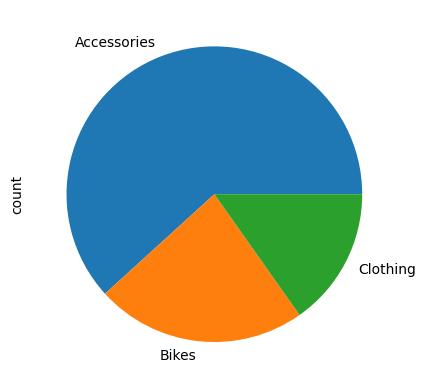

In [7]:
sales["Product Category"].value_counts().plot.pie()

In [8]:
# Summary of total revenue by category
sp = sales.pivot_table(
    index=["Date", "Product Category"],
    values=["Total Revenue", "Profit", "Margin"],
    aggfunc="sum",
)
sp


Margin  Profit  Total Revenue
Date       Product Category                                 
2011-01-01 Bikes             0.362963     196            540
2011-01-04 Bikes             0.378033     592           1566
2011-01-05 Bikes             0.378033     296            783
2011-01-08 Bikes             0.363393     407           1120
2011-01-09 Bikes             0.363316     618           1701
...                               ...     ...            ...
2016-07-29 Accessories       2.526905    1141           1800
2016-07-30 Accessories       0.628571     308            490
           Clothing          0.625000      15             24
2016-07-31 Accessories       2.257143     630           1008
           Clothing          0.868571     784           2020

[2721 rows x 3 columns]

<Axes: xlabel='Date,Product Category'>

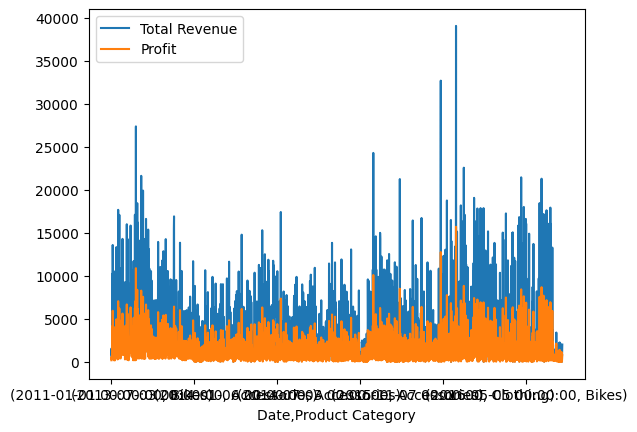

In [9]:
sp.plot(y=["Total Revenue", "Profit"])

In [10]:
sp.reset_index()

,Date,Product Category,Margin,Profit,Total Revenue
0,2011-01-01,Bikes,0.362963,196,540
1,2011-01-04,Bikes,0.378033,592,1566
2,2011-01-05,Bikes,0.378033,296,783
3,2011-01-08,Bikes,0.363393,407,1120
4,2011-01-09,Bikes,0.363316,618,1701
...,...,...,...,...,...
2716,2016-07-29,Accessories,2.526905,1141,1800
2717,2016-07-30,Accessories,0.628571,308,490
2718,2016-07-30,Clothing,0.625000,15,24
2719,2016-07-31,Accessories,2.257143,630,1008


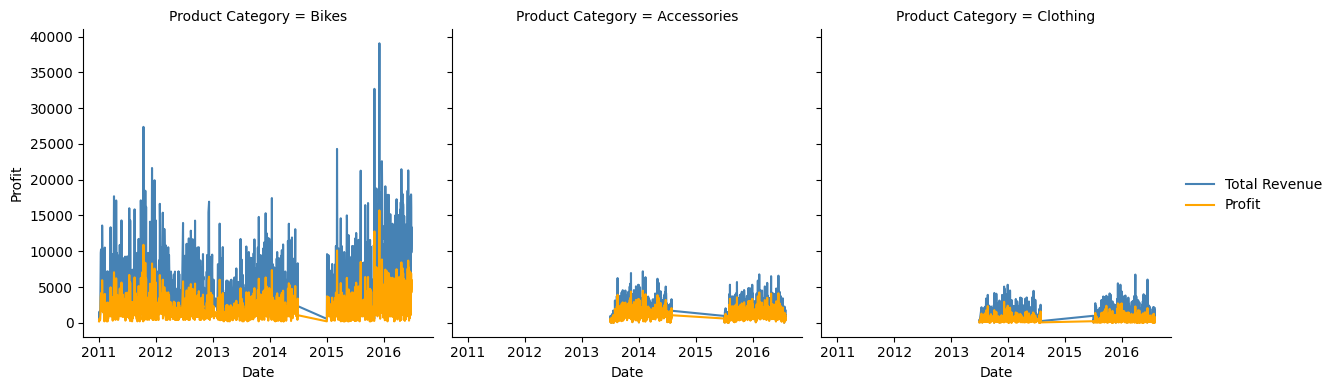

In [11]:
g = sns.FacetGrid(sp.reset_index(), col="Product Category", col_wrap=3, height=4)
g.map_dataframe(sns.lineplot, x="Date", y="Total Revenue", label="Total Revenue", color="steelblue")
g.map_dataframe(sns.lineplot, x="Date", y="Profit", label="Profit", color="orange")
g.add_legend()

In [12]:
# Using plotly express for interactive plots
import plotly.express as px
fig = px.line(
    sp.reset_index(),
    x="Date",
    y="Total Revenue",
    color="Product Category",
    title="Total Revenue by Product Category Over Time",
)
fig.show()